In [282]:
import pandas as pd
import numpy as np
import os
from analysis_utils import *
import pickle
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.gridspec as gs

from plotting_utils import add_scale_bar, save_current_fig

import matplotlib.pyplot as plt
%matplotlib widget 

In [283]:
def plot_example_supralinear_analysis(cell_data, fig, gs):
    # --- DATA PREP ---
    # Fix: Define example_ISI_300 BEFORE using it for ax1
    example_ISI_300 = cell_data.iloc[0]['Gabazine_Trace']
    ISI_300_trace = example_ISI_300[example_ISI_300 > 0][:1200]
    time_ISI_300 = np.arange(0, len(ISI_300_trace) * 0.05, 0.05)

    # Filter for ISI 100
    ISI_100_example = cell_data[(cell_data['ISI'] == 100) & (cell_data["Pathway"] == 'Perforant')]
    
    # Handle Expected Trace
    ISI_100_expected_trace = ISI_100_example.iloc[0]['Expected_EPSP_Trace'][200:6500]
    time_ISI_100_expected = np.arange(0, len(ISI_100_expected_trace) * 0.05, 0.05)

    # Handle Measured Trace
    ISI_100_measured_raw = ISI_100_example.iloc[0]['Gabazine_Trace']
    ISI_100_measured_trace = align_to_baseline(ISI_100_measured_raw) 
    time_ISI_100_measured = np.arange(0, len(ISI_100_measured_trace) * 0.05, 0.05)

    # --- PLOTTING ---
    # AX1: Unitary
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(time_ISI_300, ISI_300_trace, color='black') 
    add_scale_bar(ax1, 100, 1, x_pos=1.5, y_pos=0.1)
    ax1.set_title("Unitary EPSP Trace")

    # AX2: Comparison
    ax2 = fig.add_subplot(gs[0, 2:6])
    ax2.plot(time_ISI_100_expected, ISI_100_expected_trace, label='Expected - Linear Summation')
    ax2.plot(time_ISI_100_measured, ISI_100_measured_trace, color='red', label='Measured - Without Inhibition')
    ax2.set_title("100ms ISI")
    ax2.legend(loc='lower center', fontsize='small')

    # AX3: Supralinear (Subtraction)
    ax3 = fig.add_subplot(gs[0, 6:8])
    min_len = min(len(ISI_100_measured_trace), len(ISI_100_expected_trace))
    # +100 is likely an offset for visualization; ensure it's intended
    ISI_100_supralinear_trace = (ISI_100_measured_trace[:min_len] + 100) - ISI_100_expected_trace[:min_len]
    ISI_100_supralinear_time = np.arange(0, min_len * 0.05, 0.05)
    
    ax3.plot(ISI_100_supralinear_time, ISI_100_supralinear_trace, color='blue')
    ax3.set_title("Supralinear Trace")

    # Clean up all axes
    for ax in [ax1, ax2, ax3]:
        ax.axis('off')

In [284]:
file_path = '/Users/samgritz/Desktop/Rutgers/Milstein_Lab/Code/Rutgers-Neuroscience-PhD/GNB1_Paper_Analysis/paper_data/E_I_data/E_I_traces_for_plotting.pkl'

with open(file_path, 'rb') as file:
    # Load the object from the file
    df = pickle.load(file)

In [285]:
df

,Cell_ID,Genotype,Sex,ISI,Channel,Pathway,Control_Trace,Gabazine_Trace,Gabazine + ETX_Trace,estimated_inhibition_Trace,Expected_EPSP_Trace,Gabazine + ML297_Trace,Gabazine + Baclofen_Trace,_Trace,control_Trace,Gabazine + MCPG_Trace,gabazine_Trace,Gabazine + Baclofen _Trace
0,20250514_c2,GNB1,Female,300,channel_1,Perforant,"[0.005199253156575878, -0.005748976903025967, ...","[-0.017392354288877716, -0.006444124161996949,...","[0.033950461477942895, 0.0448986914852109, 0.0...","[-0.022591607445453594, -0.0006951472589709819...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20250514_c2,GNB1,Female,300,channel_2,Schaffer,"[-0.03906361642007047, -0.006218926443082751, ...","[0.00594522064047472, -0.02689946949348136, 0....","[0.019577425997084674, 0.019577425967170825, -...","[0.04500883706054519, -0.020680543050398608, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260115_c2,WT,Male,300,channel_2,Schaffer,"[0.03530804209213301, -0.01395899336676365, 0....","[0.003777138907210542, -0.0454898956997809, 0....",NaN,"[-0.031530903184922465, -0.03153090233301725, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260115_c2,WT,Male,100,channel_2,Schaffer,"[-0.057149761187176296, -0.024305070828887665,...","[0.06322602854733361, -0.03530804192180881, -0...",NaN,"[0.12037578973450991, -0.011002971092921143, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260115_c2,WT,Male,50,channel_2,Schaffer,"[-0.02972444485425285, -0.02972444485425285, 0...","[0.019542590244967073, 0.019542590244967073, -...",NaN,"[0.049267035099219925, 0.049267035099219925, -...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,20260113_c1,GNB1,Male,300,Basal_Stratum_Oriens,Basal_Stratum_Oriens,"[-0.01647210961748158, 0.016372580262389153, -...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
758,20260113_c1,GNB1,Male,100,Basal_Stratum_Oriens,Basal_Stratum_Oriens,"[0.05325816196832989, -0.04527590708865148, 0....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
759,20260113_c1,GNB1,Male,50,Basal_Stratum_Oriens,Basal_Stratum_Oriens,"[0.02074191929197866, 0.08643129886493739, -0....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
760,20260113_c1,GNB1,Male,25,Basal_Stratum_Oriens,Basal_Stratum_Oriens,"[0.014730345625096675, -0.050959033455072245, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [286]:
def align_to_baseline(trace):
    baseline_samples = 1
    if trace is not None and len(trace) > baseline_samples:
        baseline = np.mean(trace[:baseline_samples])
        return trace - baseline
    return trace

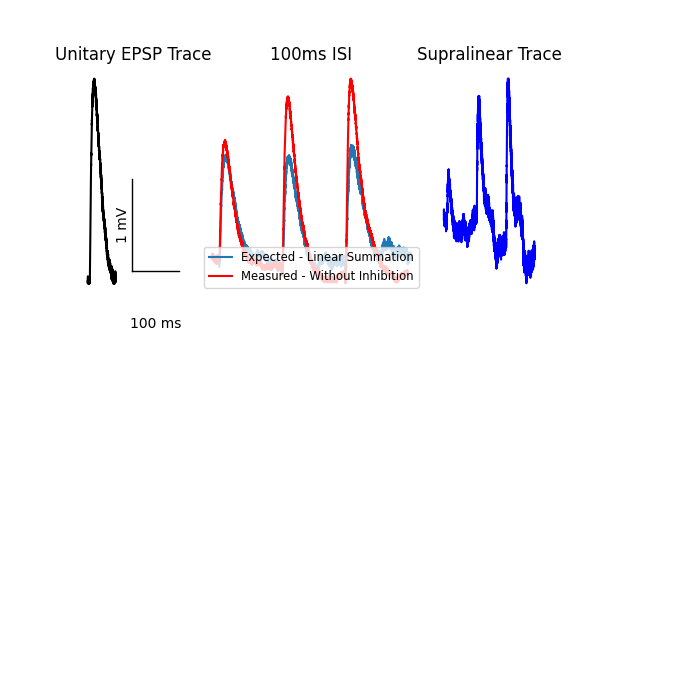

✓ Saved Figure: Supralinear_E_I_Analysis (.pdf, .svg, .png)


In [287]:
cm_to_inch = 1 / 2.54
fig_width, fig_height = 17.6 * cm_to_inch, 17.6 * cm_to_inch
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(nrows=2, ncols=10, left=0.12, right=0.95, top=0.90, bottom=0.12,
              wspace=0.45, hspace=0.40)

plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240905_c3'], fig, gs)
plt.show()

save_current_fig('Supralinear_E_I_Analysis')

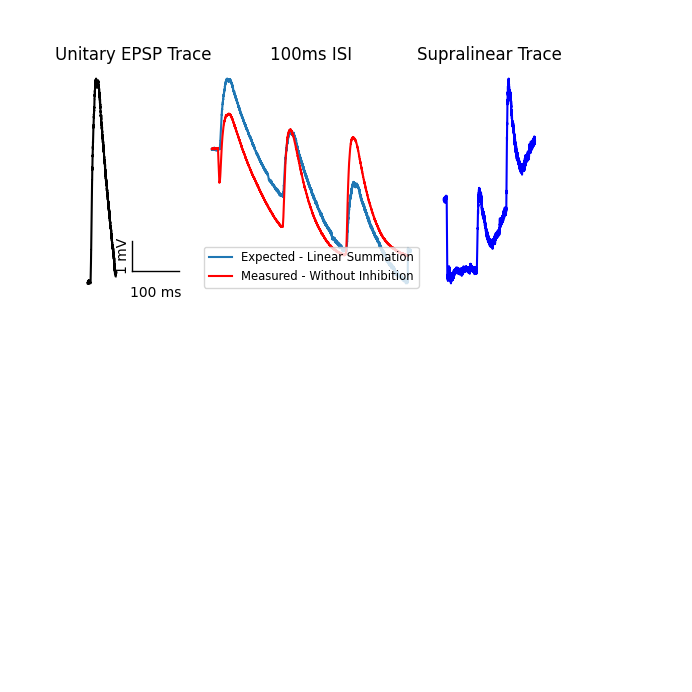

In [ ]:
# cm_to_inch = 1 / 2.54
# fig_width, fig_height = 17.6 * cm_to_inch, 17.6 * cm_to_inch
# fig = plt.figure(figsize=(fig_width, fig_height))
# gs = GridSpec(nrows=2, ncols=10, left=0.12, right=0.95, top=0.90, bottom=0.12,
#               wspace=0.45, hspace=0.40)
              
# plot_example_supralinear_analysis(df[df['Cell_ID'] == '20240522_c1'], fig, gs)